In [65]:
import os
os.environ["PATH"] = "/opt/homebrew/bin:/opt/homebrew/sbin:" + os.environ.get("PATH", "")

In [66]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline



In [ ]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        out =  Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out
    
    def tanh(self): 
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2)

        out._backward = _backward
        
        return out
    
    def exp(self): 
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float numbers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        # f(x) = x^n
        # d/dx = nx^n-1
        
        def _backward():
            self.grad = (self.data * other ** other - 1) * out.grad

        out._backward = _backward

        return out;


    
    def __truediv__(self, other):
        return self * other**-1
        
    def backward(self): 
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(o)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    


In [68]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b
e.label='e'
d = e + c
d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label='L'


In [69]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [70]:
d._op

'+'

In [71]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

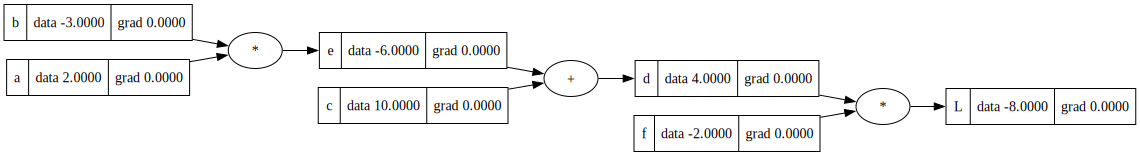

In [72]:
draw_dot(L)

In [73]:
# WANT dL / da

# dL / de = -2
# de / da = -3
# dL / de * de / da = 6


# de / db = 2
# de / db * dL / de = -4
# L = loss, we want Loss to approach zero 

L.grad = 1
a.grad = 6
b.grad = -4
e.grad = -2
c.grad = -2
f.grad=4.0
d.grad = -2.0



In [74]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


In [75]:
def lol():
    h = 0.0001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label='e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0 + h, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label='e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data

    print ((L2 - L1) / h)

lol()




-4.000000000008441


In [ ]:
# Inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

# Weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# Bias of the neuron
b = Value(6.8813735870195432, label = 'b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n= x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x2w2._backward()
# x1w1._backward()

# o = tanh(n)
# do/dn = 1 - tanh(n)**2
# o._backward = 1 - tanh(x)**2
# n.grad = o.backward(n)

draw_dot(o)

In [ ]:
a = Value(2.0)
b = Value(4.0)
print a / b